# **Práctica 8** - Propiedades fotométricas de galaxias de tipo temprano
**Cátedra Sistemas Estelares**

Notebook elaborada por Iván López (2020) y modificada por Gabriel Ferrero (2022)

Para conocer más sobre las herramientas usadas, visitar:

*   https://photutils.readthedocs.io/en/stable/isophote.html
*   https://github.com/astropy/photutils-datasets/blob/master/notebooks/isophote/

Aquí se puede encontrar información específica sobre el proceso de ajuste de las isofotas:

*   https://photutils.readthedocs.io/en/stable/api/photutils.isophote.Ellipse.html#photutils.isophote.Ellipse.fit_image


In [12]:
import numpy as np              
import matplotlib.pyplot as plt 
from astropy.io import fits     # Paquete para trabajar con archivos fits
from astropy.wcs import WCS     # Paquete para trabajar con WCS (World Coordinate System)
import astropy.units as u
from astropy.visualization import ImageNormalize, ZScaleInterval, LinearStretch, simple_norm
from astropy.table import Column  # tarea para manejar tablas de astropy
from photutils import EllipticalAperture
from photutils.isophote import EllipseGeometry, Ellipse # Cargamos los paquetes para isofotas
plt.style.use('sisest.mplstyle')

In [13]:
with fits.open('./ESO-325-G004_g.fits') as hdul:      # Con "with" podemos leer una archivo y despues borrarlo de la memoria
    hdul.info()
    hdr = hdul[0].header                              # Guardamos el header en la variable hdr
    data = hdul[0].data                               # Guardamos la información de la imagen en un arreglo (matriz de (2202 x 2102))
    wcs = WCS(hdr)                                    # Guardamos la información de la transformación de coordenadas

with fits.open('./mascara.fits') as hdul:             # lo mismo hacemos con la máscara
    hdul.info()
    data_mask = hdul[0].data                          # la máscara se guarda en data_mask

Filename: ./ESO-325-G004_g.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      71   (2202, 2102)   float32   
Filename: ./mascara.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      35   (2202, 2102)   int32   


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


### Ejercicio 1

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

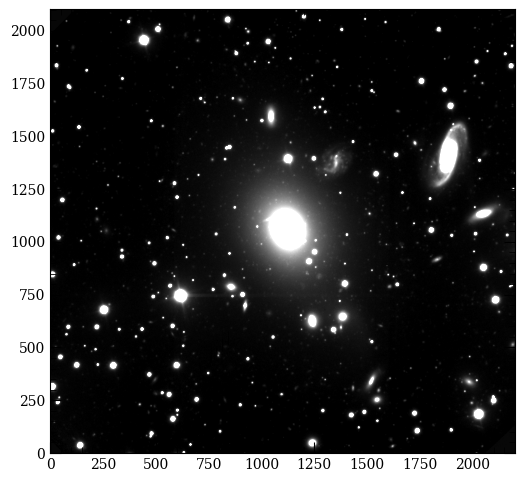

In [14]:
# para obtener estimaciones iniciales de una isofota (elíptica)

%matplotlib widget
fig = plt.figure(figsize=(6,6), dpi=100)
plt.imshow(data, 
           vmin = 0., # Todo lo que sea menor a 0 se va a ver negro, arriba de 1000 blanco
           vmax = 1000.,                 # esta línea con 1000. para trazar isofota, 125000 para ver centro
           origin = 'lower', cmap='gray')
plt.show()

In [15]:
# calculamos y guardamos las estimaciones iniciales

# extremos semieje mayor
xa1, ya1 = 1075, 1149 # indicamos coordenadas de los extremos del semieje mayor
xa2, ya2 = 1180, 978 
# extremos semieje menor
xb1, yb1 = 1057, 1005# lo mismo para el eje menor
xb2, yb2 = 1186, 1115
# centro galaxia
x_ce, y_ce = 1124, 1060# coordenadas centro galaxia

# ahora con esos datos estimamos semiejes, elipticidad y ángulo de posición

sma = np.sqrt((xa1-xa2)**2+(ya1-ya2)**2)   # semieje mayor
b_est = np.sqrt((xb1-xb2)**2+(yb1-yb2)**2) # semieje menor
eps = 1-b_est/sma # elipticidad
pa = np.arctan2((ya1-ya2),(xa1-xa2)) #* (180./np.pi) # Position Angle=ángulo de inclinación del eje principal
                                                     # medido desde el eje x en dir antihoraria

# atención al ángulo de posición!!! Hay que ponerlo de la manera en que mide los ángulos ellipse (desde el eje x positivo
# hacia el eje y positivo)

print(x_ce,y_ce,sma,b_est,eps,pa*(180./np.pi))

1124 1060 200.66389809828772 169.53170794869024 0.15514594525791847 121.5513849483135


### Ejercicio 2

In [16]:
# para ver todo el header de la imagen
#hdr
scale = 0.146       # [arcsec/pix]
exptime =  240.4946 # [segundos]                                                  
airmass =  1.039

### Ejercicio 3

Obtenga los ajustes isofotales utilizando, en $\texttt{Python}$, $\texttt{photutils.isophote.Ellipse}$ (ver ${\it Notebook}$ para $\texttt{Python}$ que se encuentra en el Classroom) o con la tarea $\texttt{ellipse}$ de $\texttt{IRAF}$.

Note que, en la tabla de salida, la columna $\texttt{SMA}$ contiene la longitud del semieje mayor medida en píxeles. Para los gráficos siguientes, debe expresar el semieje mayor en segundos de arco. 
Además, el brillo superficial de cada isofota está expresado en intensidad (medida en ADU) por píxel al cuadrado. Deberá convertirlo a magnitudes estándar por segundo de arco al cuadrado, teniendo en cuenta la escala de la imagen y su tiempo de exposición.

Obtenga también el ángulo de posición de las isofotas en el sistema estándar (desde el Norte hacia el Este).

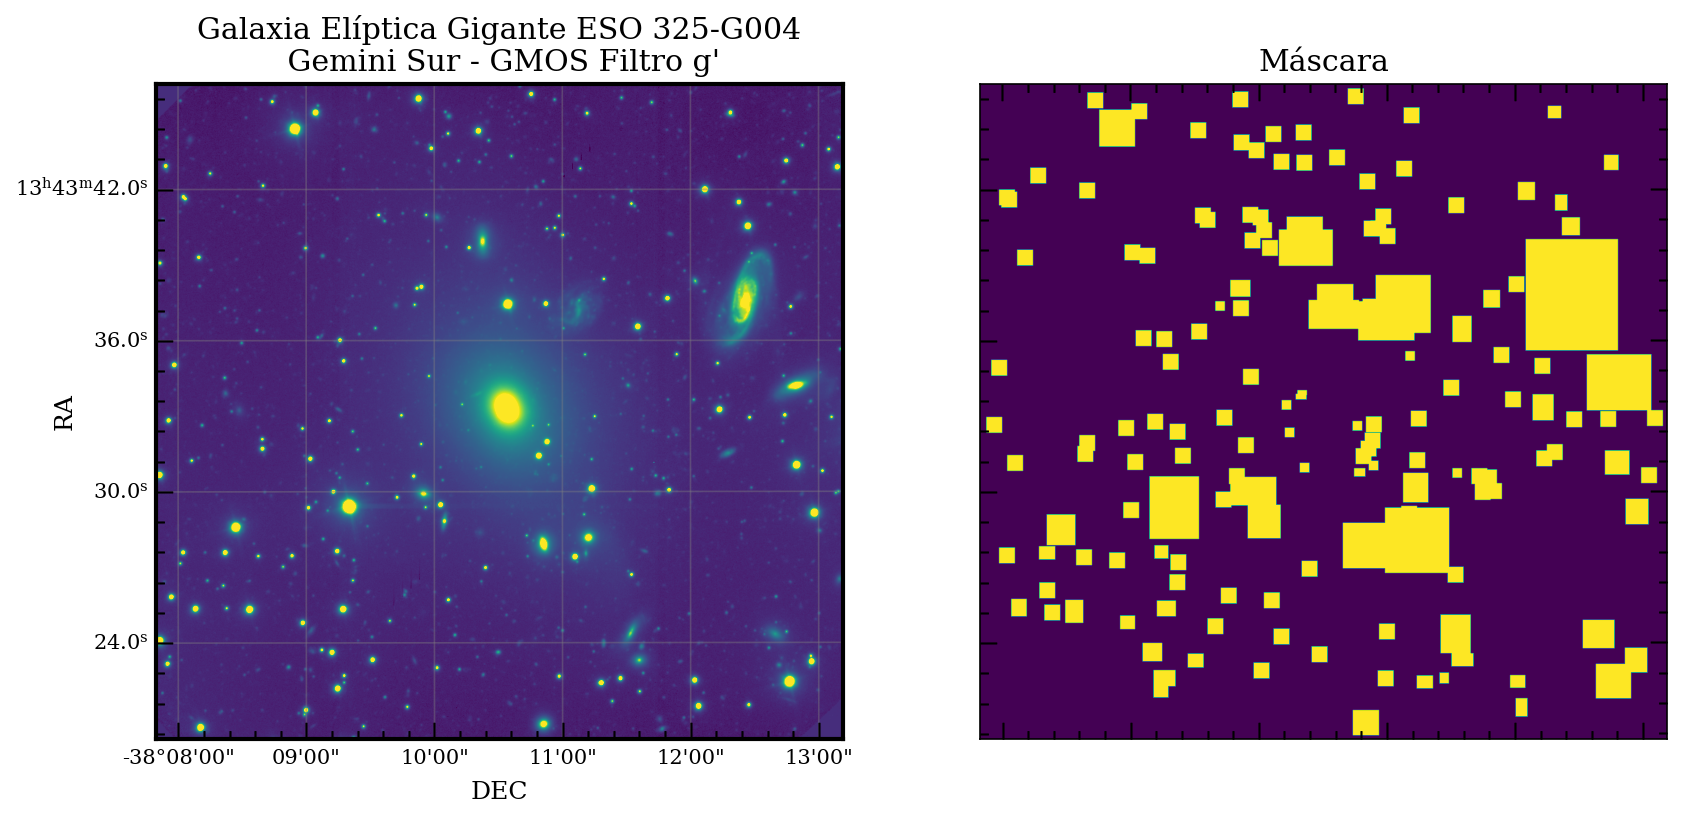

In [17]:
# para obtener un mejor despliegue de la imagen y la máscara
%matplotlib inline
interval = ZScaleInterval()                               # Definimos una función para representar los niveles de brillo
vmin, vmax = interval.get_limits(data)                    # cambiando percent entre 0 y 100 cambia el contraste y el brillo
norm = simple_norm(data, 'sqrt', percent=99.)             # Esta función tiene una escala sqrt, para ver mejor los lugares 
                                                          # donde la galaxia tiene poco brillo


fig = plt.subplots(figsize=(13,6), dpi=150)
ax1 = plt.subplot(121, projection = wcs)                  # Posición del subplot y proyección en coordenadas celestes para los ejes
pos1 = ax1.imshow(data, norm = norm, origin='lower')      # imshow convierte la matriz en imagen
ax1.grid(color = 'grey', ls = 'solid', alpha = 0.4)       # agregamos grilla
ax1.set_title('Galaxia Elíptica Gigante ESO 325-G004\n Gemini Sur - GMOS Filtro g\'')

# en este bloque definimos los ejes en coordenadas y especificamos su formato
ra = ax1.coords['ra']                 
dec = ax1.coords['dec']
dec.set_ticks(number=5)
ra.set_ticks(number=5)
ra.set_major_formatter('hh:mm:ss.s')
dec.set_major_formatter('dd:mm:ss')
ra.set_axislabel('RA', minpad=-2)
dec.set_axislabel('DEC')
ra.set_ticks_position('l')
ra.set_ticklabel_position('l')
ra.set_axislabel_position('l')
dec.set_ticks_position('b')
dec.set_ticklabel_position('b')
dec.set_axislabel_position('b')
ax1.coords.frame.set_linewidth(2)

ax2 = plt.subplot(122, projection = wcs)
pos2 = ax2.imshow(data_mask, origin = 'lower')            # Mostramos la máscara
ax2.set_title('Máscara')

plt.show() #la imagen tiene un tamaño angular de aprox 1/6 de la Luna

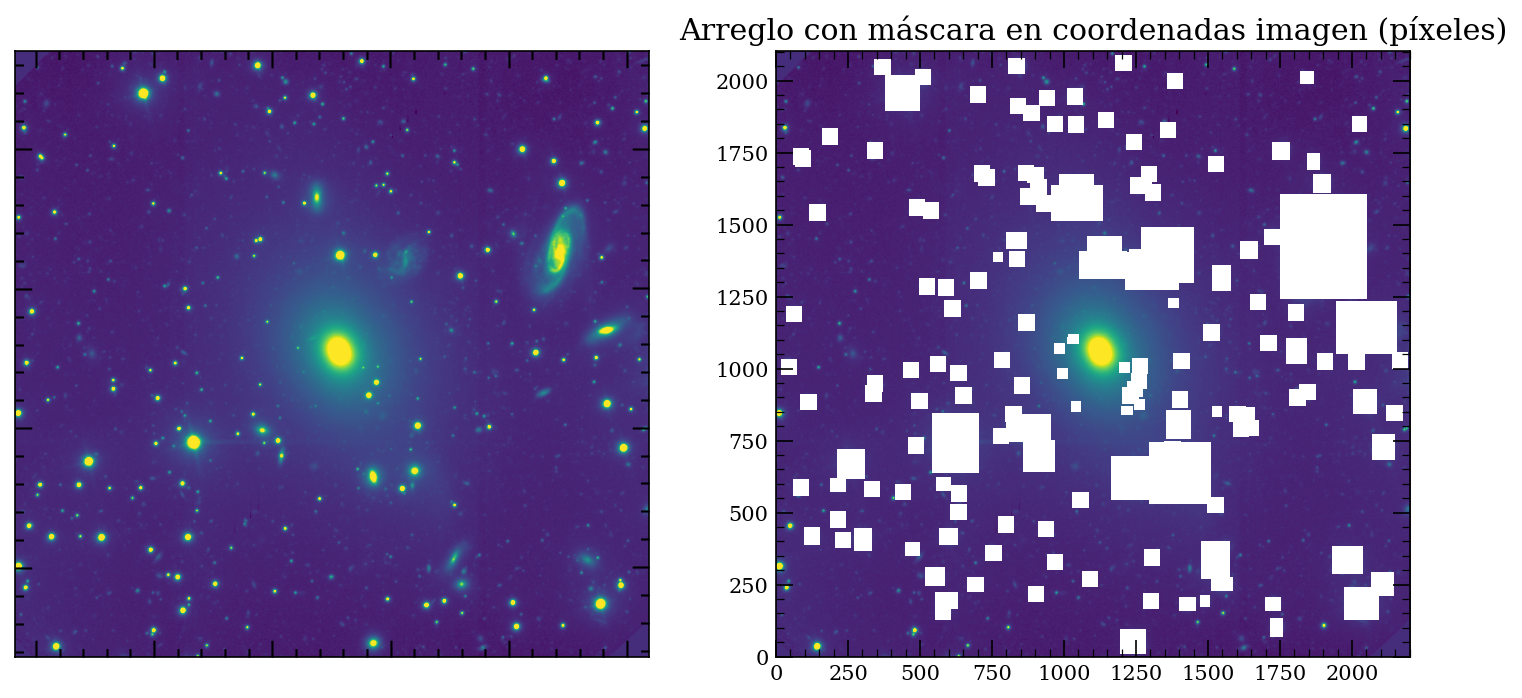

In [18]:
# Enmascaramos la imagen
import numpy.ma as ma
data2 = ma.masked_where(data_mask==1, data, copy=True)  # Función que enmascara en data los pixeles con data_mask==1 y 
                                                        # los guarda en data2
fig = plt.subplots(figsize=(12,12), dpi=150)
ax1 = plt.subplot(121, projection = wcs)                  
pos1 = ax1.imshow(data, norm = norm, origin='lower')
ax2 = plt.subplot(122)
pos2 = ax2.imshow(data2, norm=norm ,origin='lower')
ax2.set_title('Arreglo con máscara en coordenadas imagen (píxeles)')

plt.show()

#### Realizamos la fotometría: TARDA VARIOS MINUTOS

In [19]:
# Definimos isofota inicial como una elipse con los parámetros iniciales
g = EllipseGeometry(x_ce, y_ce, sma, eps, pa)

# Buscamos el centro de la galaxia en la imagen, suponiendo que la elipse es aproximadamente la que nosotros le damos
g.find_center(data2)

# Definimos el objeto Ellipse como la geometría de la isofota g aplicada al arreglo data2
ellipse = Ellipse(data2, geometry = g)  

# Y ajustamos las isofotas:
isolist = ellipse.fit_image(minsma = 1., maxsma = 1000, sclip = 4., nclip = 4)
# generamos así una clase, llamada isolist, que contiene arreglos con la salida del ajuste
# las isofotas se guardan en un objeto (clase) cuyos atributos son arreglos con los parámetros de las isofotas

INFO: Found center at x0 = 1124.0, y0 = 1061.0 [photutils.isophote.geometry]


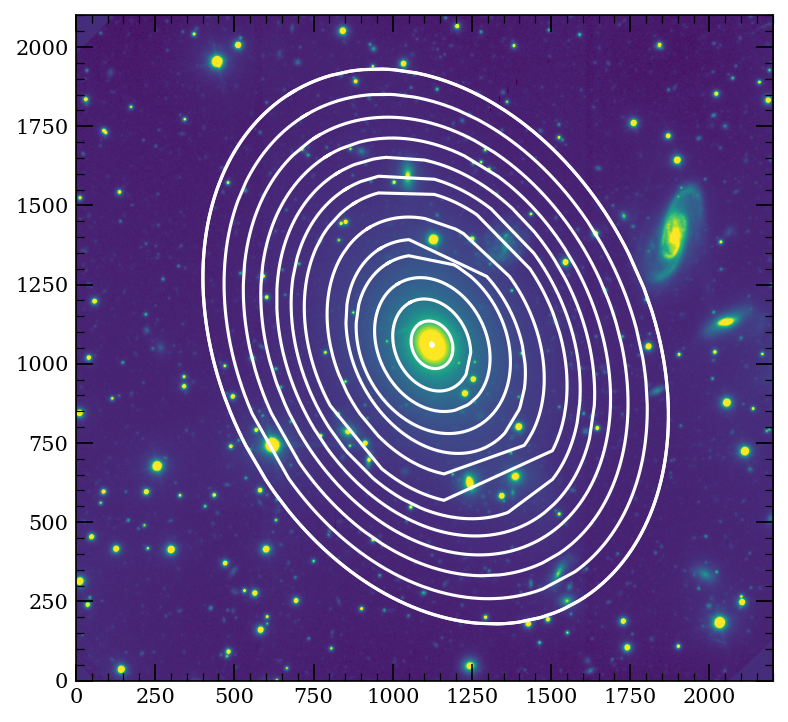

In [20]:
# Gráfico de las isofotas:
fig = plt.subplots(figsize=(6,6), dpi=150)                             

smas = np.linspace(5, 1000, 15)                               # lista de valores aprox. del semieje mayor (15 valores)

ax1 = plt.subplot(111)
pos1 = ax1.imshow(data, norm = norm, origin = 'lower')

for sma in smas:
    iso = isolist.get_closest(sma)                            # busca la isofota con el semieje mayor más cercano a sma
    x, y, = iso.sampled_coordinates()                         # genera arreglos con las coord. de los puntos de la isofota
    ax1.plot(x, y, color='white')

plt.show()

Agregamos en el objeto isolist el semieje mayor en arcsec, el brillo superficial en mag/arcsec$^2$ y el ángulo de posición en el sistema estándar

In [21]:
isolist.smarcsec = isolist.sma * scale # cambio unidades semieje mayor                                   
isolist.mu_inst = -2.5 * np.log10(isolist.intens/(exptime * scale**2)) # ecuación magnitud instrumental (BRILLO INSTR)

kg = 0.18 # coef. extinción
zg = 28.33 # punto cero fotometría
Ag = 0.2 #  extinción interestelar e intergaláctica

isolist.mu_std = isolist.mu_inst - kg * (airmass -1.) + zg - Ag #Pasamos de magnitud instrumental a estándar. [magnitudes g por arcsec^2]
isolist.pa_std = 180. - isolist.pa * (180./np.pi) # pasar de ángulo de posición Ellipse a estándar

### Ejercicio 4

Grafique el ángulo de posición de las isofotas, su elipticidad y las coordenadas de sus centros $(x_0,y_0)$ en función de su semieje mayor. Describa esos gráficos e indique las posibles causas de sus variaciones. Es posible apreciar el efecto de seeing en los gráficos?

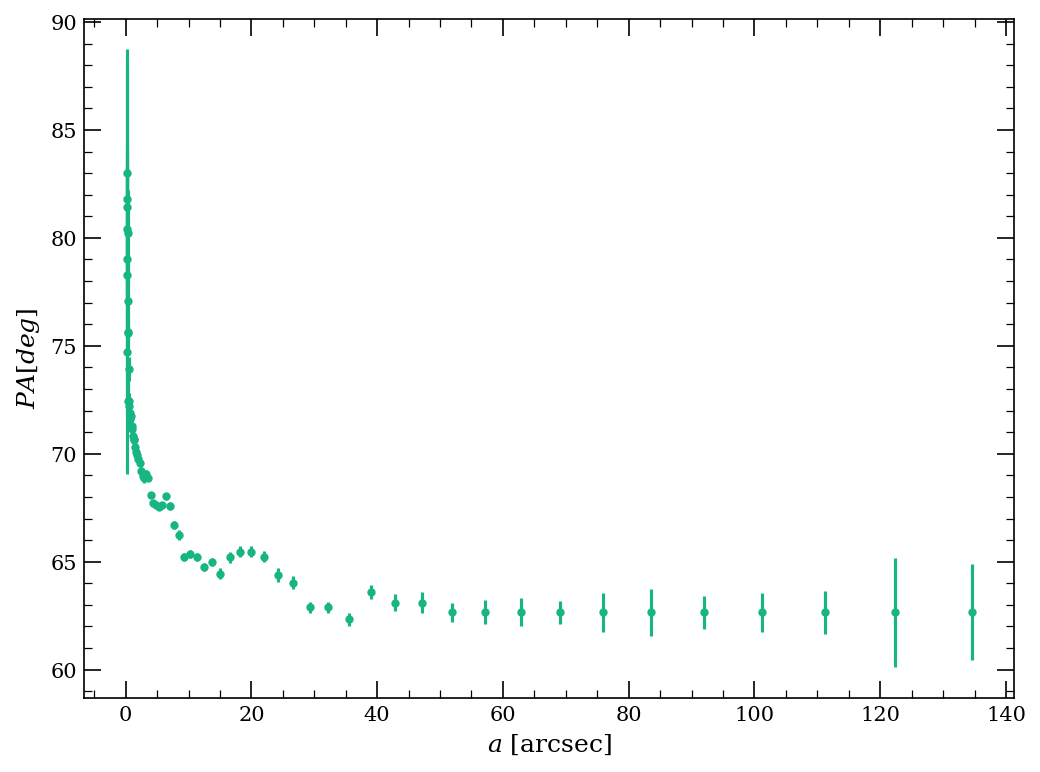

In [22]:
# Ángulo de posición PA en función del semieje mayor en arcsec
fig = plt.figure(figsize = (8,6), dpi=150)
plt.errorbar(isolist.smarcsec, isolist.pa_std, yerr = isolist.pa_err* (180./np.pi), fmt = '.', c='#17B583')
plt.xlabel('$a$ [arcsec]')
plt.ylabel('$PA [deg]$')
plt.show()

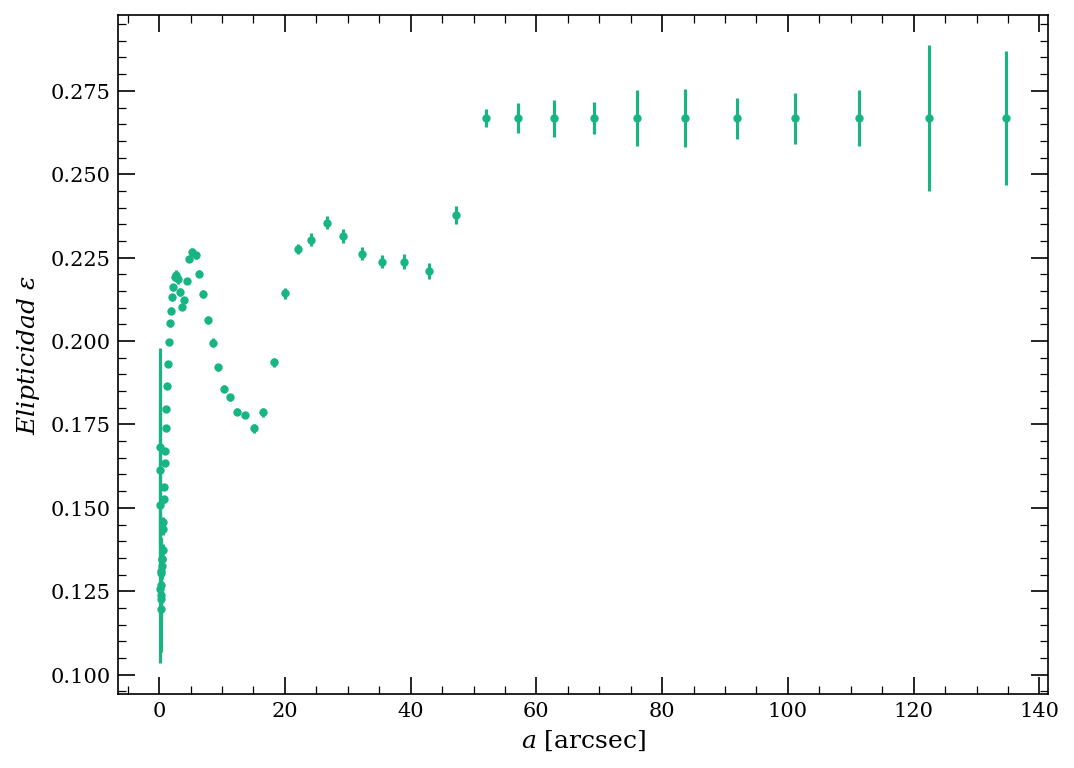

In [23]:
# Elipticidad en función del semieje mayor en arcsec

fig = plt.figure(figsize = (8,6), dpi=150)
plt.errorbar(isolist.smarcsec, isolist.eps, yerr = isolist.ellip_err, fmt = '.', c='#17B583')
plt.xlabel('$a$ [arcsec]')
plt.ylabel('$Elipticidad~\epsilon$')
plt.show()

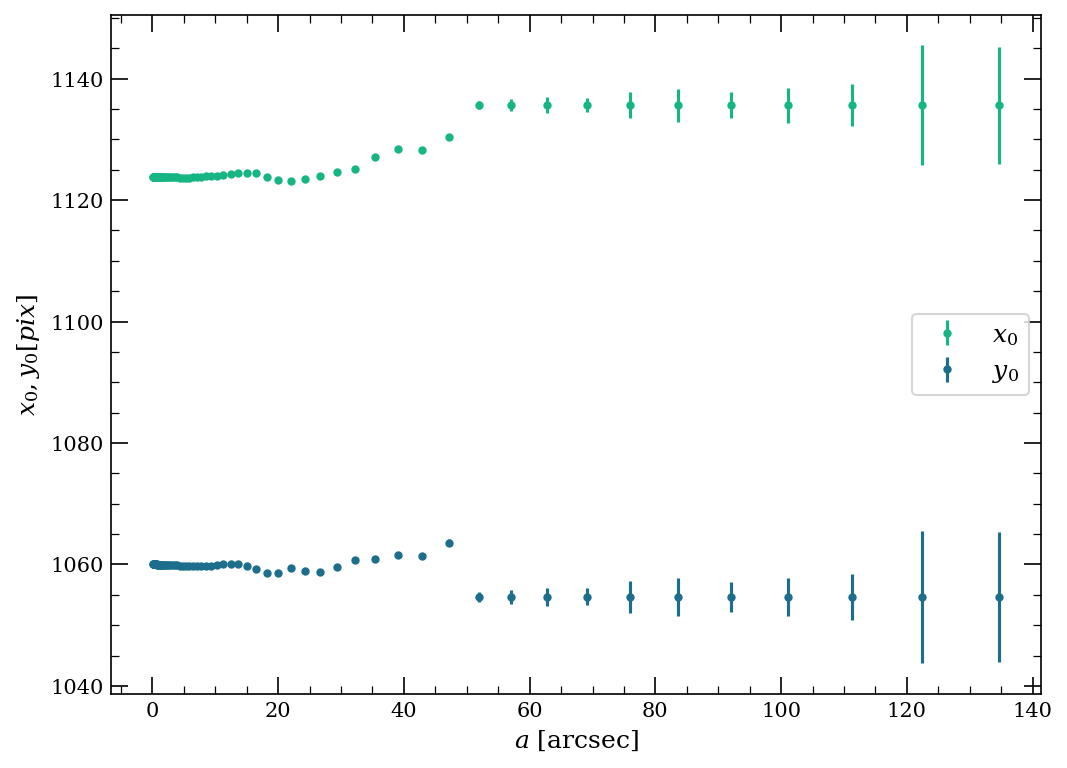

In [24]:
# Centros de las isofotas en función del semieje mayor en arcsec

fig = plt.figure(figsize = (8,6), dpi=150)
plt.errorbar(isolist.smarcsec, isolist.x0, yerr = isolist.x0_err, fmt = '.', label='$x_0$', c='#17B583')
plt.errorbar(isolist.smarcsec, isolist.y0, yerr = isolist.y0_err, fmt = '.', label='$y_0$', c='#1C6E8C')
plt.xlabel('$a$ [arcsec]')
plt.ylabel('$x_0, y_0 [pix]$')

plt.legend(loc='center right', fontsize='large')
plt.show()

### Ejercicio 5

Realice un gráfico del flujo integrado dentro de cada isofota en función del radio equivalente de las isofotas. Esa sería la {\bf curva de crecimiento del flujo}. Obtenga, además, una estimación directa del  radio equivalente efectivo ($r_{ef}$).

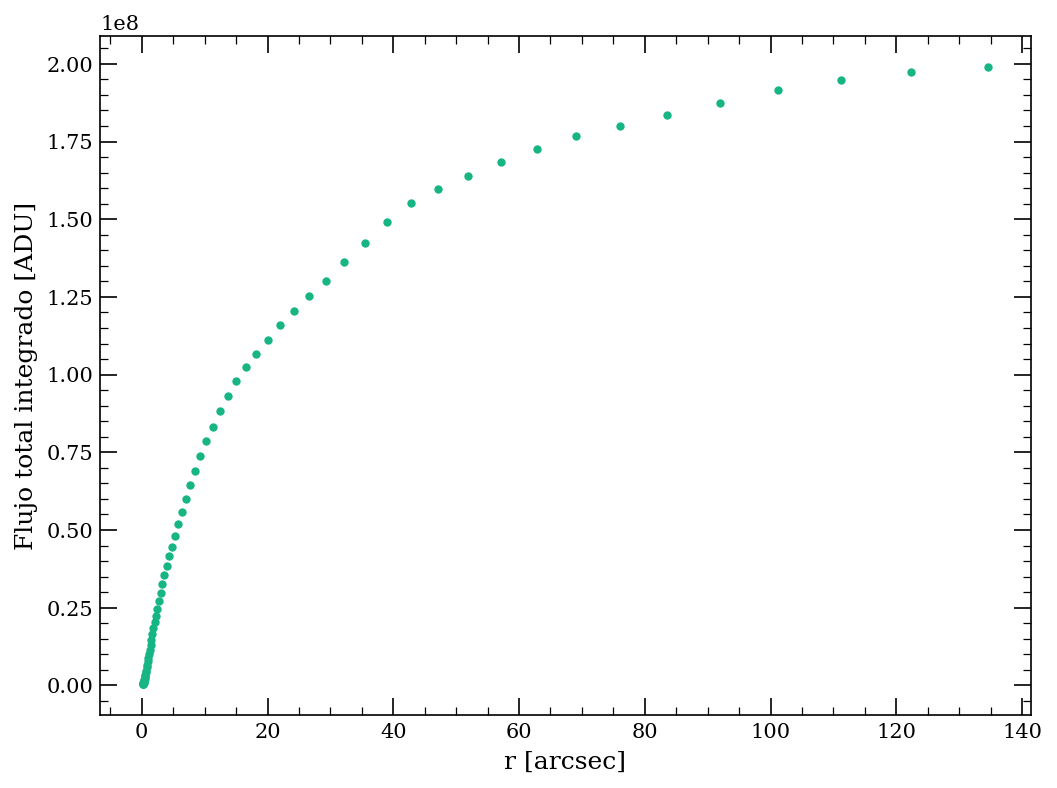

array([0.17378999])

In [26]:
# Definimos y computamos los radios equivalentes de las isofotas

%matplotlib inline
def req(a,elip):
    b = (1-elip)*a
    req = np.sqrt(a*b)
    return req

isolist.req = req(isolist.smarcsec, isolist.eps)

#curva de crecimiento del flujo

fig = plt.figure(figsize=(8,6), dpi=150)
plt.errorbar(isolist.smarcsec, isolist.tflux_e, fmt='.', c='#17B583')

plt.xlabel('r [arcsec]')
plt.ylabel('Flujo total integrado [ADU]')
plt.show()

#flujo maximo
flux_max=np.amax(isolist.tflux_e)
flux_ef = flux_max/2
isolist.eps[(15.<isolist.smarcsec)&(isolist.smarcsec<16.)]
#  print(flux_ef, )
# Con el flujo efectivo podemos calcular el semieje mayor efectivo, 

### Ejercicio 6

Transforme al sistema estándar el perfil de brillo superficial instrumental, obteniendo así, el {\bf perfil de brillo superficial} buscado. Utilice el coeficiente de extinción atmosférica $k_g=0.18$ y el punto de cero para la magnitud $z_g=28.33$~mag. Corrija además por extinción interestelar utilizando los valores disponibles en \href{https://ned.ipac.caltech.edu}{NED} ($A_g=0.200$). 

Incluya en el gráfico del perfil de brillo superficial el valor del brillo del cielo durante las observaciones, que ha sido estimado por la cátedra como $\mu_g'=22.4$~mag/arcsec$^2$

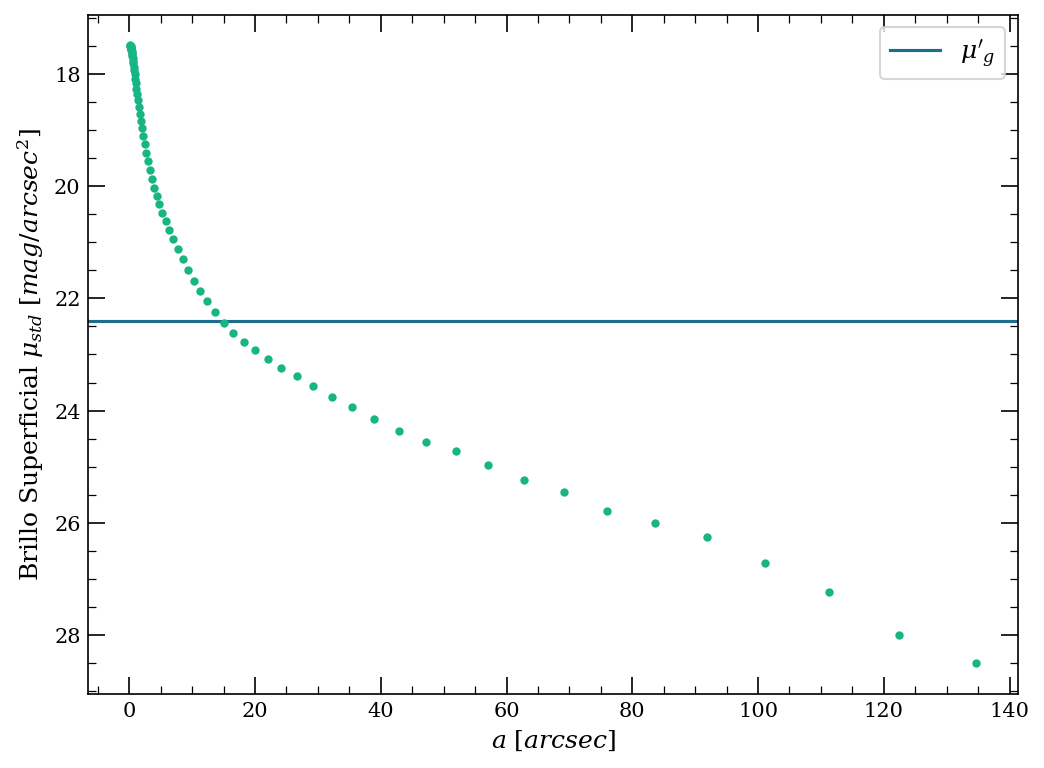

In [33]:
# Gráfico del perfil de brillo superficial

fig = plt.figure(figsize=(8,6), dpi=150)
plt.errorbar(isolist.smarcsec, isolist.mu_std, fmt='.', c='#17B583')
plt.axhline (22.4, 0, 1, color= '#1C6E8C', label ='$\mu\'_g$')

plt.gca().invert_yaxis()

plt.xlabel('$a~[arcsec]$')
plt.ylabel('Brillo Superficial $\mu_{std}~[mag/arcsec^2]$')
plt.legend(fontsize='large')
plt.show()

### Ejercicio 7

Obtenga valores para los radios isofotales $r_{25}$ y $r_{27}$. 
    Con el valor de $r_{ef}$ obtenido, calcule además el valor del brillo superficial efectivo en la banda $g'$. Esto es, $\mu_{ef}$ en el filtro $g'$.

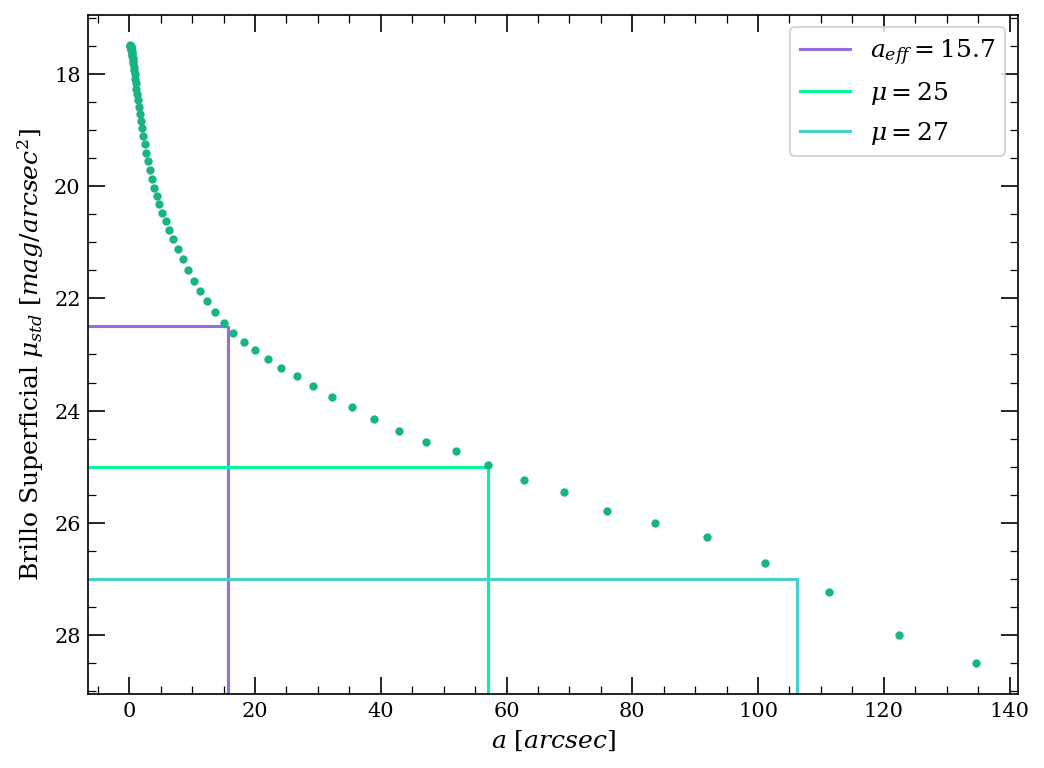

In [93]:
# Gráfico del perfil de brillo superficial
%matplotlib inline
fig = plt.figure(figsize=(8,6), dpi=150)
plt.errorbar(isolist.smarcsec, isolist.mu_std, fmt='.', c='#17B583')

plt.axhline (22.5, 0, 0.147, color= 'mediumpurple')
plt.axvline (15.7, 0, 0.54, color= 'mediumpurple', label ='$a_{eff}=15.7$')

plt.axhline (25, 0, 0.43, color= 'mediumspringgreen', label ='$\mu=25$')
plt.axvline (57.09, 0, 0.34, color= 'mediumspringgreen')

plt.axhline (27, 0, 0.76, color= 'mediumturquoise', label ='$\mu=27$')
plt.axvline (106.2, 0, 0.17, color= 'mediumturquoise')



plt.gca().invert_yaxis()

plt.xlabel('$a~[arcsec]$')
plt.ylabel('Brillo Superficial $\mu_{std}~[mag/arcsec^2]$')
plt.legend(fontsize='large')
plt.show()

In [94]:
# r25 y r27
print(isolist.smarcsec[(isolist.mu_std>24.9)&(isolist.mu_std<25.1)])
print(isolist.smarcsec[(isolist.mu_std>26.5)&(isolist.mu_std<27.3)])
print('r25=', np.sqrt(57.1**2*(1-0.26)),'arcsec')
print('r27=', np.sqrt(106.2**2*(1-0.26)),'arcsec')

# 
print('$\mu_{eff}=$',isolist.mu_std[(isolist.smarcsec>15)&(isolist.smarcsec<16)])

[57.09142676]
[101.14094508 111.25503959]
r25= 49.1192772748134 arcsec
r27= 91.3566943359927 arcsec
$\mu_{eff}=$ [22.43051893]


### Ejercicio 8
Realice una estimación de la magnitud total de la galaxia en la banda $g'$.

In [98]:
Mtot = -2.5 * np.log10 (flux_max / exptime) - (kg*(airmass-1)) + zg - Ag
Mtot

13.328330537479461